# Derive Herwig/Pythia Mass Scale Factors

This notebook reproduces the spline-based Herwig/Pythia scale-factor derivation used in the rho workflow, but for jet mass using the inputs in `inputs/massInputs`.

In [5]:
import os
import sys
import pickle as pkl

import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
from scipy.interpolate import CubicSpline, UnivariateSpline

sys.path.append("./src")

from unfold.tools import binning
from unfold.utils.integrate_and_rebin import rebin_hist

hep.style.use("CMS")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.Set1.colors)

os.getcwd()

'/mnt/8A04C21E04C20CDF/wsLinux/unfold'

In [9]:
with open("./inputs/massInputs/mass_pythia_all.pkl", "rb") as handle:
    output_pythia = pkl.load(handle)

with open("./inputs/massInputs/mass_herwig_all.pkl", "rb") as handle:
    output_herwig = pkl.load(handle)

pt_labels = [
    r"0 - 200 GeV",
    r"200 - 290 GeV",
    r"290 - 400 GeV",
    r"400 - $\infty$ GeV",
]
groomed = False
npt = len(pt_labels)
bins = binning.bin_edges(groomed=groomed)
mass_edges_by_pt = bins.gen_mass_edges_by_pt
pt_edges = np.asarray(bins.pt_edges, dtype=float)

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


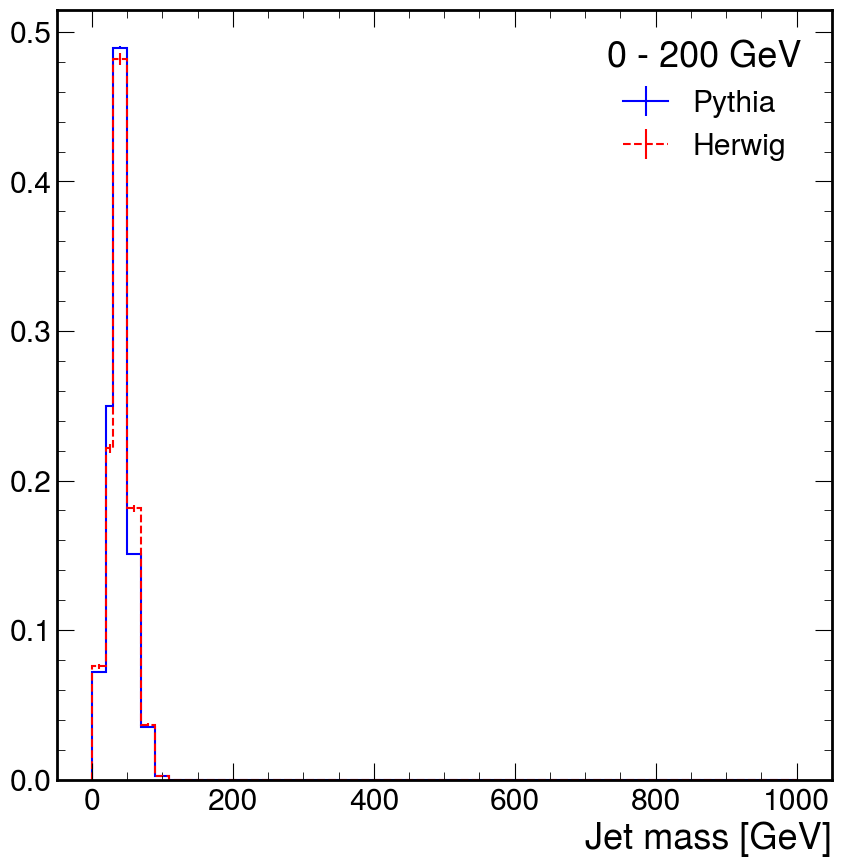

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


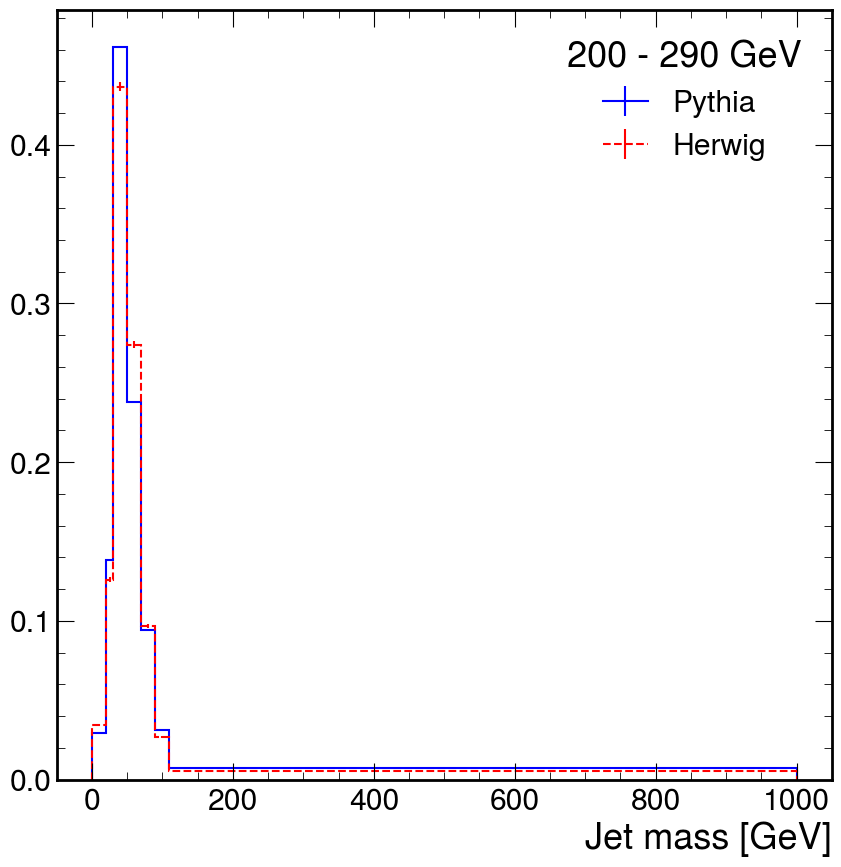

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


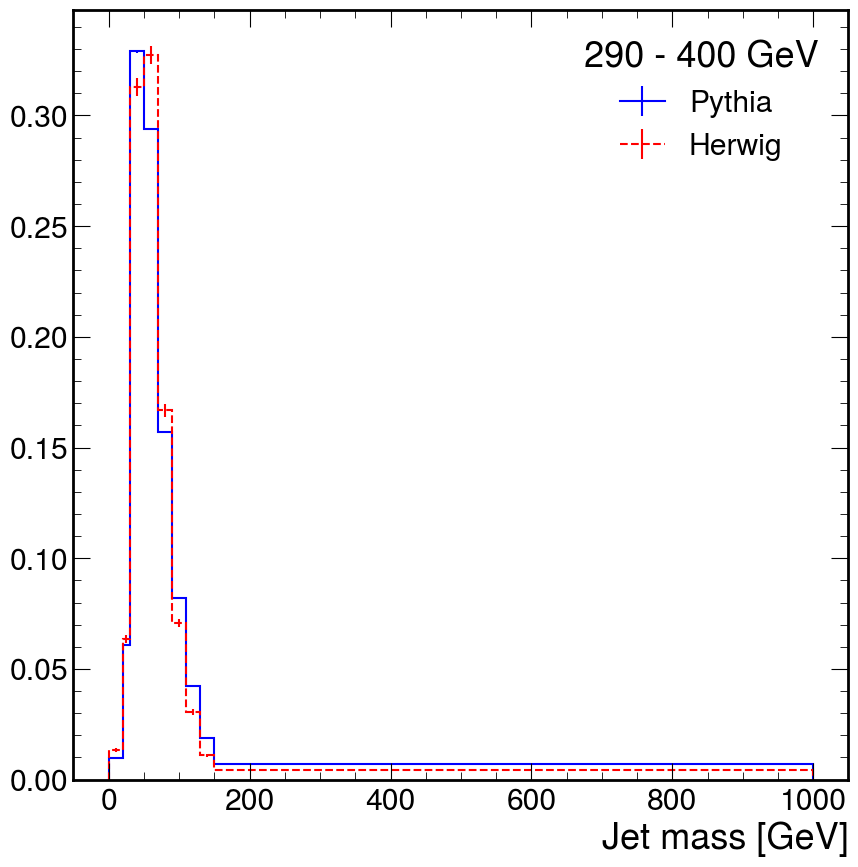

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


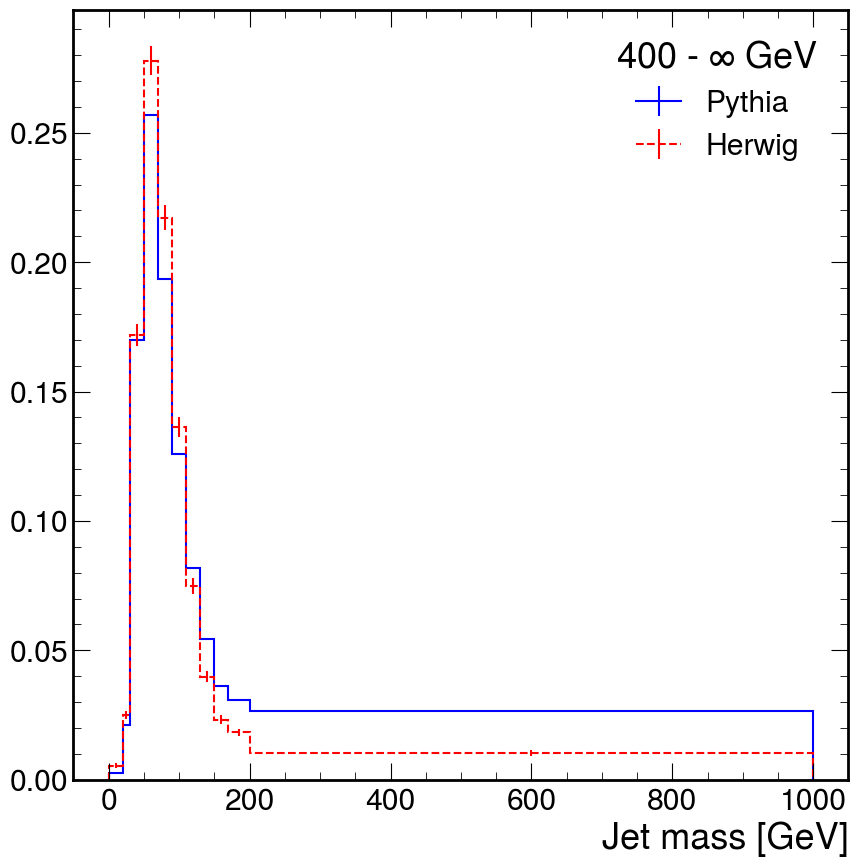

In [10]:
def generator_key(groomed_flag):
    return "ptjet_mjet_g_gen" if groomed_flag else "ptjet_mjet_u_gen"


def generator_projection(output, groomed_flag):
    return output[generator_key(groomed_flag)].project("ptgen", "mgen", "systematic")


def normalized_mass_spectrum(output, pt_index, mass_edges, groomed_flag):
    hist_gen = generator_projection(output, groomed_flag)
    hist_gen = rebin_hist(hist_gen, "mgen", mass_edges)

    values = np.asarray(hist_gen[pt_index, :, "nominal"].values(), dtype=float)
    variances = np.asarray(hist_gen[pt_index, :, "nominal"].variances(), dtype=float)
    errors = np.sqrt(np.clip(variances, 0.0, None))

    total = values.sum()
    if total <= 0:
        raise ValueError(f"Empty mass spectrum for pt bin {pt_index}.")

    return values / total, errors / total


for i in range(npt):
    mass_edges = np.asarray(mass_edges_by_pt[i], dtype=float)
    pythia_vals, pythia_errs = normalized_mass_spectrum(output_pythia, i, mass_edges, groomed)
    herwig_vals, herwig_errs = normalized_mass_spectrum(output_herwig, i, mass_edges, groomed)

    hep.histplot(pythia_vals, bins=mass_edges, yerr=pythia_errs, label="Pythia", histtype="step", color="blue")
    hep.histplot(herwig_vals, bins=mass_edges, yerr=herwig_errs, label="Herwig", histtype="step", color="red", ls = "--")
    plt.xlabel("Jet mass [GeV]")
    plt.legend(title=pt_labels[i])
    plt.show()

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


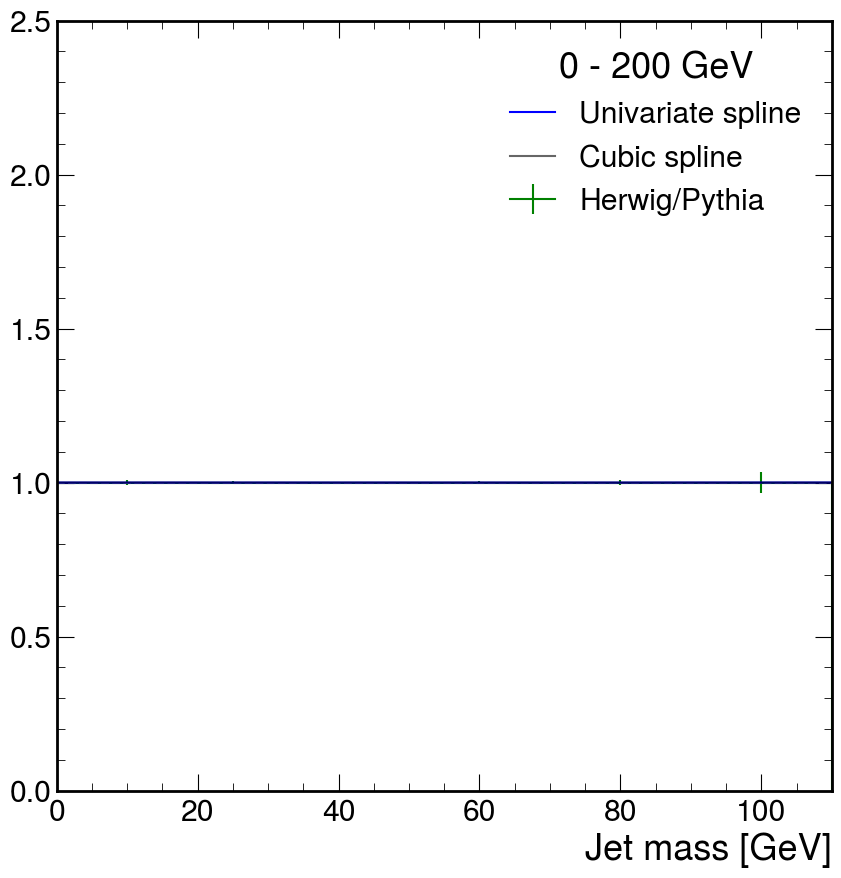

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


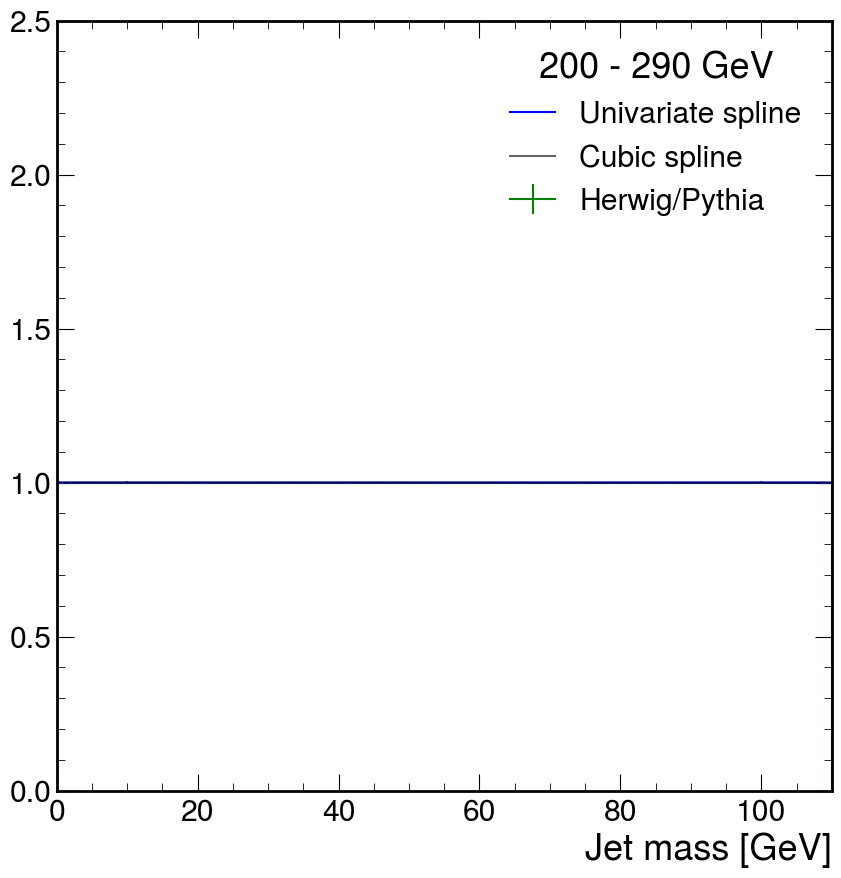

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


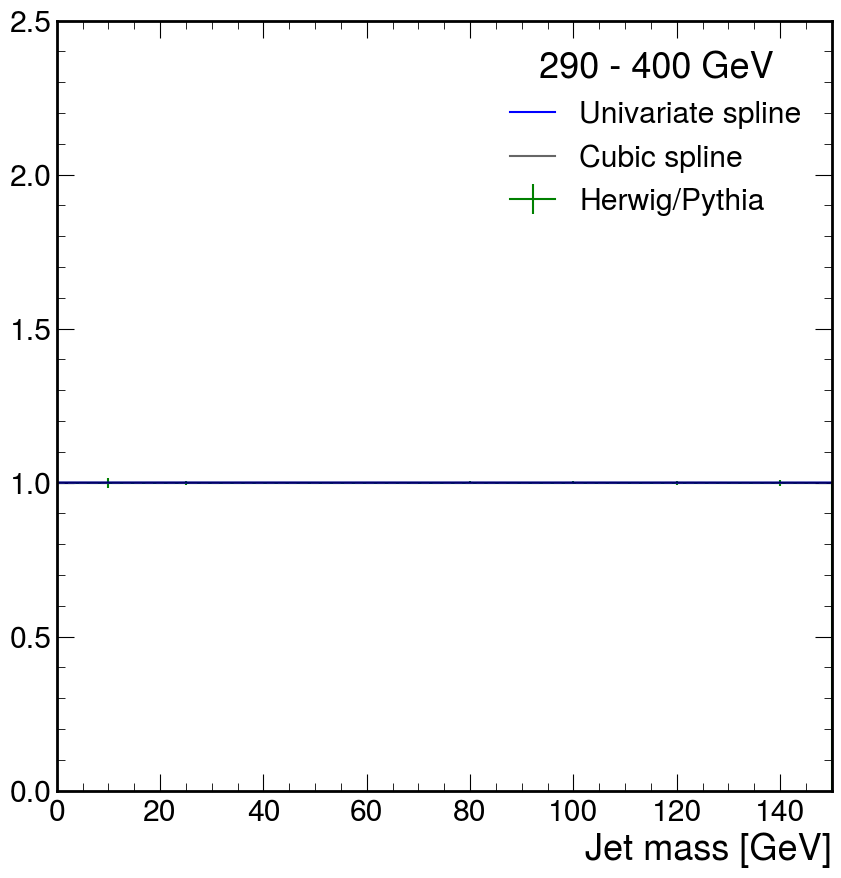

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


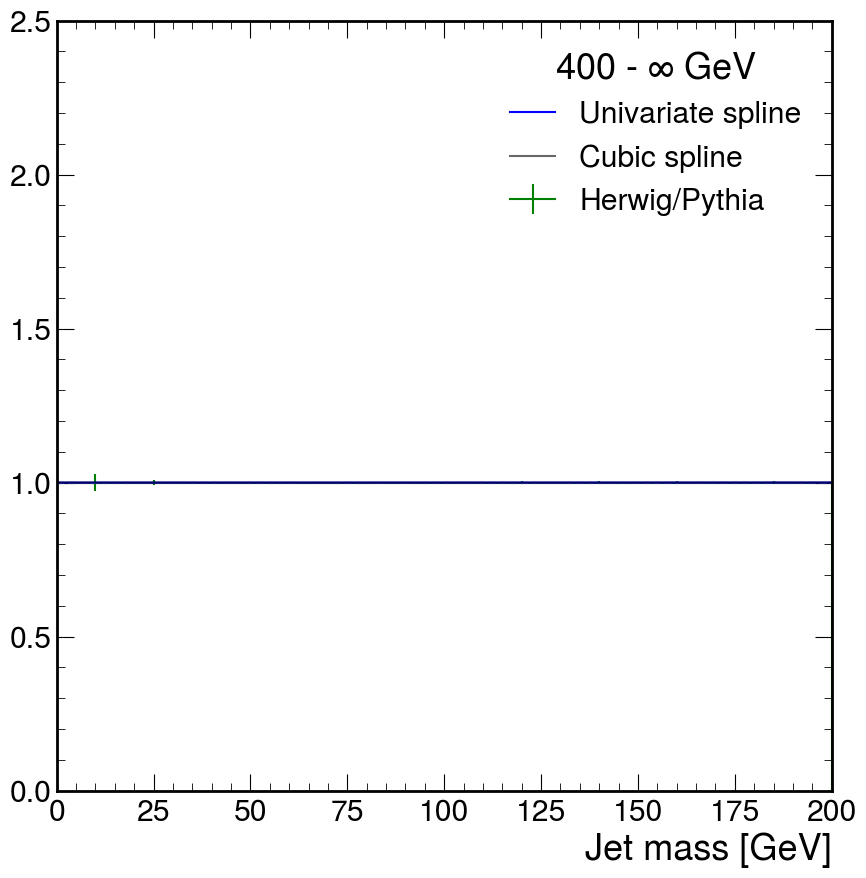

'./data/mass_spline_ungroomed.npz'

In [4]:
spline_list = []
mass_grids = []
weight_grids = []

for i in range(npt):
    mass_edges = np.asarray(mass_edges_by_pt[i], dtype=float)
    fit_edges = mass_edges[:-1]
    fit_upper = fit_edges[-1]

    pythia_vals, pythia_errs = normalized_mass_spectrum(output_pythia, i, mass_edges, groomed)
    herwig_vals, herwig_errs = normalized_mass_spectrum(output_herwig, i, mass_edges, groomed)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = herwig_vals / pythia_vals
        ratio_errs = ratio * np.sqrt((herwig_errs / herwig_vals) ** 2 + (pythia_errs / pythia_vals) ** 2)

    fit_ratio = ratio[:-1]
    fit_ratio_errs = ratio_errs[:-1]
    bin_centers = 0.5 * (fit_edges[:-1] + fit_edges[1:])
    mask = (fit_ratio > 0) & (fit_ratio_errs > 0) & np.isfinite(fit_ratio) & np.isfinite(fit_ratio_errs)
    if mask.sum() < 3:
        raise ValueError(f"Not enough valid points to fit pt bin {i}.")

    smoothness = mask.sum() * 2
    cubic = CubicSpline(bin_centers[mask], fit_ratio[mask], bc_type="natural")
    spline = UnivariateSpline(bin_centers[mask], fit_ratio[mask], w=1.0 / fit_ratio_errs[mask], k=2, s=smoothness)

    x_smooth = np.linspace(fit_edges[0], fit_upper, 400)

    hep.histplot(fit_ratio, bins=fit_edges, yerr=fit_ratio_errs, label="Herwig/Pythia", histtype="step", color="green")
    plt.hlines(1.0, fit_edges[0], fit_upper, colors="gray", linestyles="dashed")
    plt.plot(x_smooth, spline(x_smooth), "b-", label="Univariate spline")
    plt.plot(x_smooth, cubic(x_smooth), "k-", alpha=0.6, label="Cubic spline")
    plt.xlim(fit_edges[0], fit_upper)
    plt.ylim(0.0, 2.5)
    plt.xlabel("Jet mass [GeV]")
    plt.legend(title=pt_labels[i])
    plt.show()

    mass_grid = np.linspace(fit_edges[0], fit_upper, 2000)
    weight_grid = np.clip(spline(mass_grid), 0.5, 1.5)

    spline_list.append(spline)
    mass_grids.append(mass_grid)
    weight_grids.append(weight_grid)

filename = "./data/mass_spline_groomed.npz" if groomed else "./data/mass_spline_ungroomed.npz"
np.savez(
    filename,
    pt_edges=pt_edges,
    mass_grids=np.array(mass_grids, dtype=object),
    w_grids=np.array(weight_grids, dtype=object),
)

filename

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type(

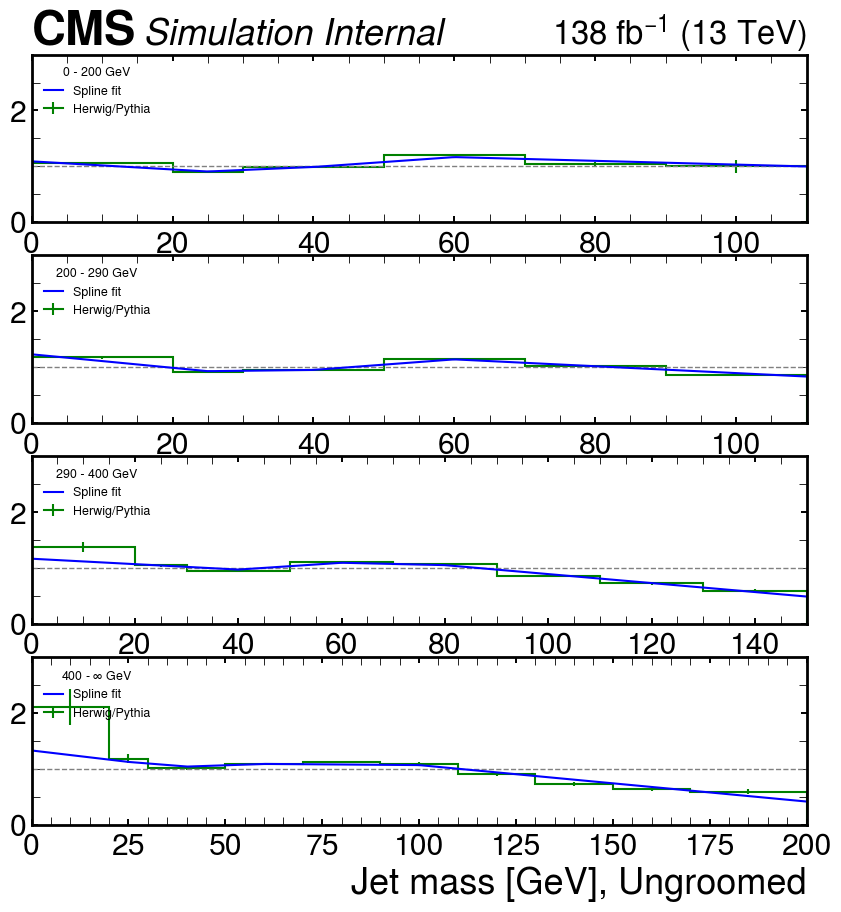

In [5]:
fig, axes = plt.subplots(
    npt,
    1,
    sharex=False,
    gridspec_kw={"hspace": 0.2},
    constrained_layout=False,
)
axes = np.atleast_1d(axes)

for i, ax in enumerate(axes):
    mass_edges = np.asarray(mass_edges_by_pt[i], dtype=float)
    fit_edges = mass_edges[:-1]
    fit_upper = fit_edges[-1]

    pythia_vals, pythia_errs = normalized_mass_spectrum(output_pythia, i, mass_edges, groomed)
    herwig_vals, herwig_errs = normalized_mass_spectrum(output_herwig, i, mass_edges, groomed)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = herwig_vals / pythia_vals
        ratio_errs = ratio * np.sqrt((herwig_errs / herwig_vals) ** 2 + (pythia_errs / pythia_vals) ** 2)

    fit_ratio = ratio[:-1]
    fit_ratio_errs = ratio_errs[:-1]
    hep.histplot(
        fit_ratio,
        bins=fit_edges,
        yerr=fit_ratio_errs,
        histtype="step",
        color="green",
        ax=ax,
        label="Herwig/Pythia",
    )
    ax.hlines(1.0, fit_edges[0], fit_upper, colors="gray", linestyles="dashed", linewidth=1.0)

    bin_centers = 0.5 * (fit_edges[:-1] + fit_edges[1:])
    mask = (fit_ratio > 0) & (fit_ratio_errs > 0) & np.isfinite(fit_ratio) & np.isfinite(fit_ratio_errs)
    smoothness = mask.sum() * 2
    spline = UnivariateSpline(bin_centers[mask], fit_ratio[mask], w=1.0 / fit_ratio_errs[mask], k=1, s=smoothness)

    x_smooth = np.linspace(fit_edges[0], fit_upper, 200)
    ax.plot(x_smooth, spline(x_smooth), "b-", linewidth=1.5, label="Spline fit")

    if i == 0:
        hep.cms.label("Internal", data=False, lumi=138, ax=ax)

    ax.set_xlim(fit_edges[0], fit_upper)
    ax.set_ylim(0.0, 3.0)
    ax.legend(title=str(pt_labels[i]), loc="upper left", fontsize=9, title_fontsize=9, frameon=False)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    ax.tick_params(direction="in", length=4, width=1.4)

axes[-1].set_xlabel("Jet mass [GeV], Groomed" if groomed else "Jet mass [GeV], Ungroomed")
plt.show()

In [26]:
check_obj = np.array(weight_grids, dtype=object)
print(np.isnan(np.concatenate([np.asarray(grid, dtype=float) for grid in check_obj])).any())

False


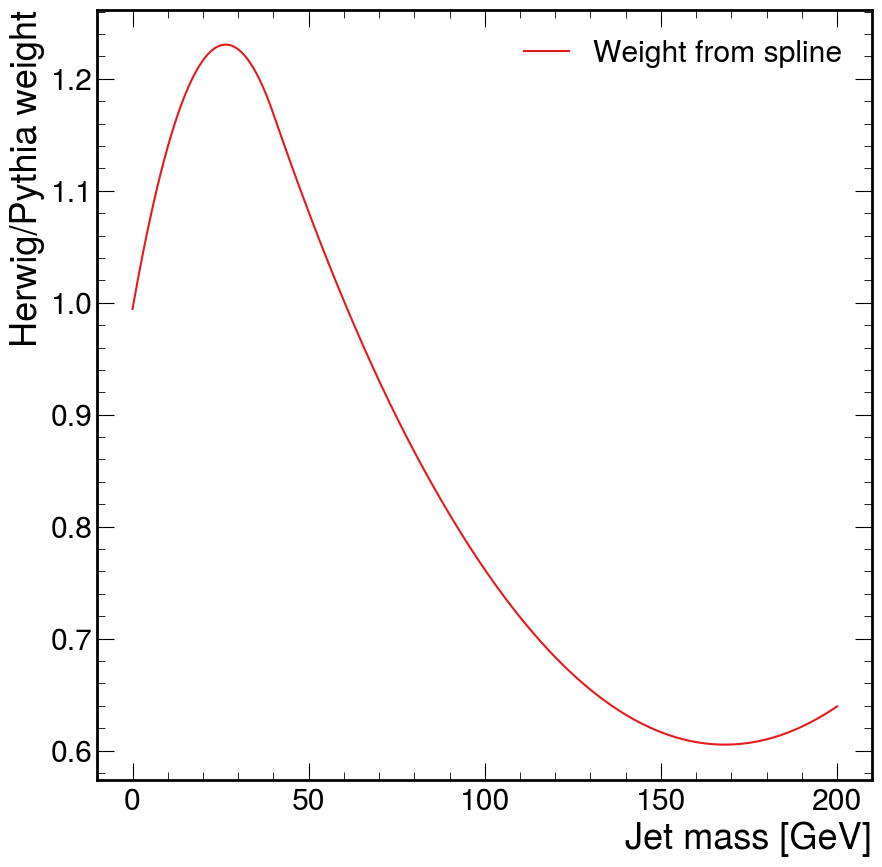

In [27]:
class PtMassWeighter:
    def __init__(self, npz_path: str):
        data = np.load(npz_path, allow_pickle=True)
        self.pt_edges = np.asarray(data["pt_edges"], dtype=float)
        self.mass_grids = data["mass_grids"]
        self.w_grids = data["w_grids"]

    def _pt_bin(self, pt: float) -> int:
        index = np.searchsorted(self.pt_edges, pt, side="right") - 1
        return int(np.clip(index, 0, len(self.pt_edges) - 2))

    def weight(self, pt: float, mass: float) -> float:
        index = self._pt_bin(pt)
        x = np.asarray(self.mass_grids[index], dtype=float)
        w = np.asarray(self.w_grids[index], dtype=float)
        return float(np.interp(mass, x, w, left=w[0], right=w[-1]))

    def weight_array(self, pt_arr, mass_arr):
        pt_arr = np.asarray(pt_arr, dtype=float)
        mass_arr = np.asarray(mass_arr, dtype=float)
        out = np.empty_like(mass_arr, dtype=float)

        pt_bins = np.searchsorted(self.pt_edges, pt_arr, side="right") - 1
        pt_bins = np.clip(pt_bins, 0, len(self.pt_edges) - 2)

        for index in range(len(self.pt_edges) - 1):
            mask = pt_bins == index
            if not np.any(mask):
                continue
            x = np.asarray(self.mass_grids[index], dtype=float)
            w = np.asarray(self.w_grids[index], dtype=float)
            out[mask] = np.interp(mass_arr[mask], x, w, left=w[0], right=w[-1])

        return out


weighter = PtMassWeighter("./data/mass_spline_groomed.npz" if groomed else "./data/mass_spline_ungroomed.npz")
mass_scan = np.linspace(mass_edges_by_pt[-1][0], mass_edges_by_pt[-1][-2], 400)
plt.plot(mass_scan, weighter.weight_array(np.full_like(mass_scan, 401.0), mass_scan), label="Weight from spline")
plt.xlabel("Jet mass [GeV]")
plt.ylabel("Herwig/Pythia weight")
plt.legend()
plt.show()